In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np
import re
import seaborn as sns

In [ ]:
time_cache = '../data/outs/0327/all_time_cache.csv'
mem = '../data/outs/0327/all_mem.csv'

try:
    df_tcache = pd.read_csv(time_cache, sep=' ')
    df_mem = pd.read_csv(mem, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado!")

Dados lidos com sucesso!


In [5]:
df_tcache.dtypes

nome           object
n               int64
m               int64
c               int64
insert          int64
extractMin      int64
dk              int64
bkmp            int64
fila           object
cpu_time        int64
wall_time       int64
l1_miss         int64
l2_ref          int64
llc_miss        int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
branch_inst     int64
branch_miss     int64
dtype: object

In [6]:
df_mem.dtypes

nome    object
n        int64
m        int64
c        int64
fila    object
mem      int64
dtype: object

In [7]:
# selecionar todos que não são MEM

df_tcache = df_tcache[~df_tcache["nome"].str.startswith("MEM")]
df_mem = df_mem[~df_mem["nome"].str.startswith("MEM")]

# Uso de memória

In [8]:
# pivot = df_mem.pivot_table(
#     index="n",
#     columns="fila",
#     values="mem",
#     aggfunc="first"
# )

# c_vals = pivot.index.to_list()
# filas = pivot.columns.to_list()

# x = np.arange(len(c_vals))
# width = 0.8 / len(filas)

# # 🎨 cores por número da fila (LVBQ)
# colors = {
#     "1": "tab:red",
#     "2": "tab:orange",
#     "3": "tab:olive",
#     "4": "tab:green",
#     "5": "tab:blue",
#     "6": "tab:purple",
# }

# plt.figure(figsize=(12, 6))

# for i, fila in enumerate(filas):

#     # ===== HEAPS (cores exclusivas) =====
#     if "BINH" in fila:
#         color = "black"
#         hatch = "xx"
        
#     elif "FIBH" in fila:
#         color = "gold"
#         hatch = ".."

#     # ===== LVBQ / LVBQDK =====
#     else:
#         # extrai número da fila (1–6)
#         m = re.match(r"\d+", fila)
#         num = m.group() if m else None

#         color = colors.get(num, "tab:gray")

#         # padrão para DK
#         hatch = "//" if "LVBQDK" in fila else None

#     plt.bar(
#         x + i * width,
#         pivot[fila].values,
#         width,
#         label=fila,
#         color=color,
#         hatch=hatch,
#         edgecolor="black"
#     )

# plt.xticks(x + width * len(filas) / 2, c_vals)
# plt.xlabel("n")
# plt.ylabel("mem")
# plt.title("Memória por n e fila")
# plt.legend(bbox_to_anchor=(1.05, 1))

# plt.tight_layout()
# plt.show()

In [9]:
# rank = (
#     df_mem
#     .sort_values(['nome', 'mem'])
#     .groupby('nome')
#     .head(6)
# )

# rank['rank'] = rank.groupby('nome').cumcount() + 1

# resultado = rank.pivot(
#     index='nome',
#     columns='rank',
#     values=['fila', 'mem']
# )

# resultado.columns = [f'{col}{rank}' for col, rank in resultado.columns]

# resultado = resultado.reset_index()

# resultado = resultado.sort_values('mem1')

# resultado

# Tempo de execução

In [10]:
df_tcache.head()

,nome,n,m,c,insert,extractMin,dk,bkmp,fila,cpu_time,wall_time,l1_miss,l2_ref,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
840,NY,264346,733846,36946,299281,299281,0,814144,1LVBQ,68,68,3242667,1763082,142263,292740532,592759898,31379,0,82901416,961343
841,NY,264346,733846,36946,298897,298897,0,710775,1LVBQ,66,66,3218294,1735865,128238,285684978,588428866,28742,0,82619426,949631
842,NY,264346,733846,36946,298704,298704,0,748419,1LVBQ,67,67,3237057,1754591,129032,288178376,590149960,30672,0,82784886,946655
843,NY,264346,733846,36946,299164,299164,0,1247227,1LVBQ,69,69,3319877,1903455,146813,297059002,604100121,24747,0,83349872,949344
844,NY,264346,733846,36946,298201,298201,0,993562,1LVBQ,67,67,3266368,1831590,135042,290416052,595941019,26205,0,82887332,946522


In [11]:
df_time = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time', 'wall_time']
].copy()
df_time

,nome,n,c,fila,cpu_time,wall_time
840,NY,264346,36946,1LVBQ,68,68
841,NY,264346,36946,1LVBQ,66,66
842,NY,264346,36946,1LVBQ,67,67
843,NY,264346,36946,1LVBQ,69,69
844,NY,264346,36946,1LVBQ,67,67
...,...,...,...,...,...,...
2515,USA,23947347,368855,FIBH,19449,19451
2516,USA,23947347,368855,FIBH,19393,19396
2517,USA,23947347,368855,FIBH,19101,19103
2518,USA,23947347,368855,FIBH,18891,18893


In [12]:
df_time["wall_cpu_ratio"] = df_time["wall_time"] / df_time["cpu_time"]
print("Min ratio", df_time["wall_cpu_ratio"].min())
print("Max ratio", df_time["wall_cpu_ratio"].max())

Min ratio 1.0
Max ratio 1.0135135135135136


Logo, CPU Bound

In [13]:
df_cpu = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time']
].copy()
df_cpu = (
    df_cpu.groupby(['nome', 'fila'], as_index=False)
      .agg(
           cpu_mean=('cpu_time', 'mean'),
           cpu_std =('cpu_time', 'std'),
           cpu_var =('cpu_time', 'var'),
           n=('n', 'first'),
      )
)
df_cpu['cpu_cv'] = df_cpu['cpu_std'] / df_cpu['cpu_mean']
df_cpu

,nome,fila,cpu_mean,cpu_std,cpu_var,n,cpu_cv
0,BAY,1LVBQ,85.8,1.549193,2.400000,321270,0.018056
1,BAY,1LVBQDK,61.5,0.707107,0.500000,321270,0.011498
2,BAY,2LVBQ,92.9,2.685351,7.211111,321270,0.028906
3,BAY,2LVBQDK,69.1,0.567646,0.322222,321270,0.008215
4,BAY,3LVBQ,83.9,0.994429,0.988889,321270,0.011853
...,...,...,...,...,...,...,...
163,W,5LVBQDK,1916.0,24.207437,586.000000,6262104,0.012634
164,W,6LVBQ,1998.4,25.250743,637.600000,6262104,0.012635
165,W,6LVBQDK,1932.6,34.121352,1164.266667,6262104,0.017656
166,W,BINH,2710.0,67.616566,4572.000000,6262104,0.024951


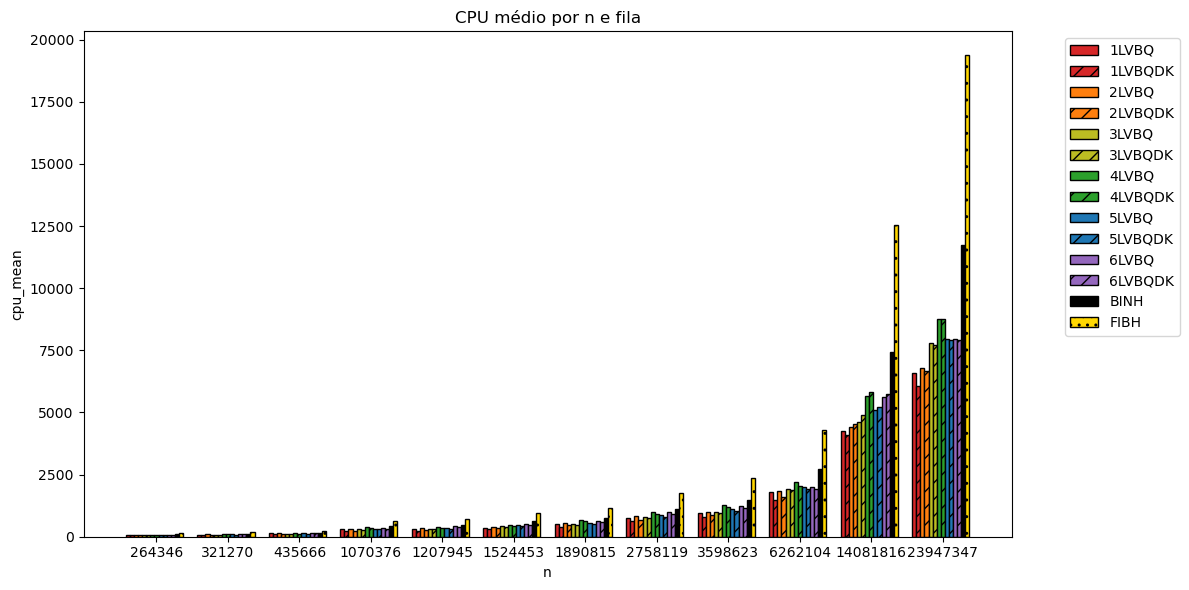

In [14]:
pivot = df_cpu.pivot_table(
    index="n",
    columns="fila",
    values="cpu_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("cpu_mean")
plt.title("CPU médio por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

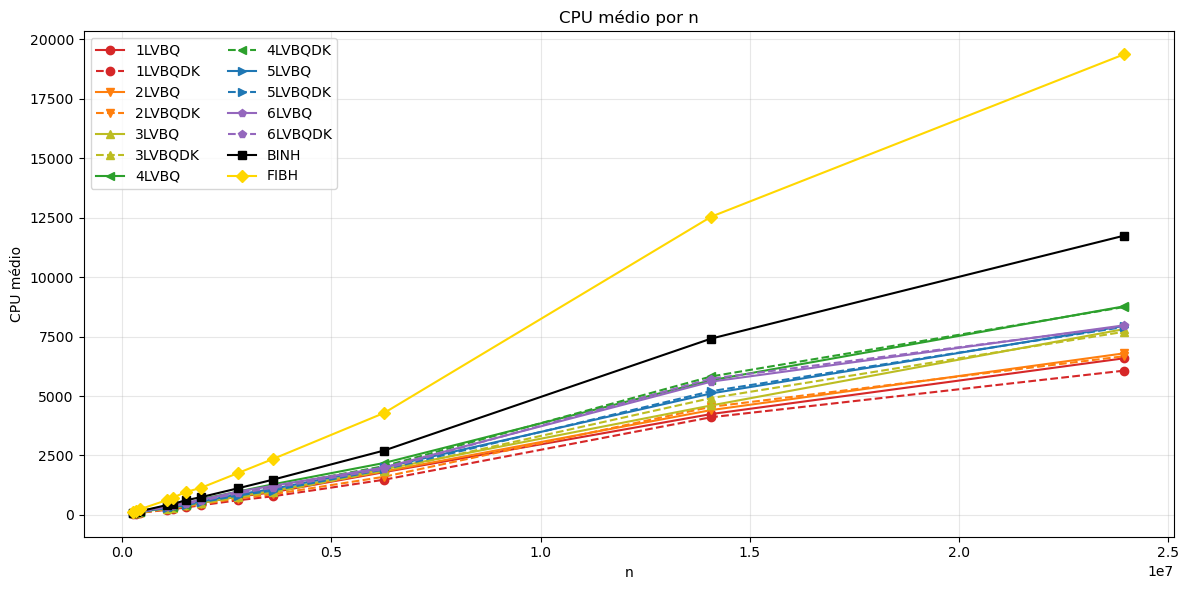

In [15]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

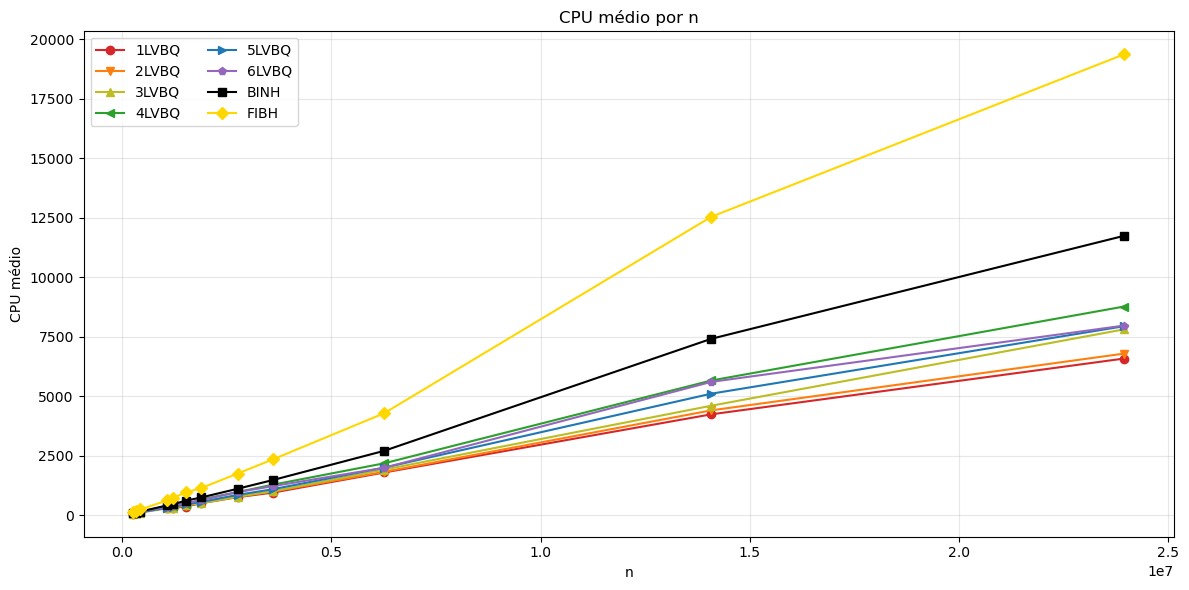

In [16]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **sem DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ$"))  # somente LVBQ sem DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ simples (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "-"  # todas LVBQ simples são sólidas
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

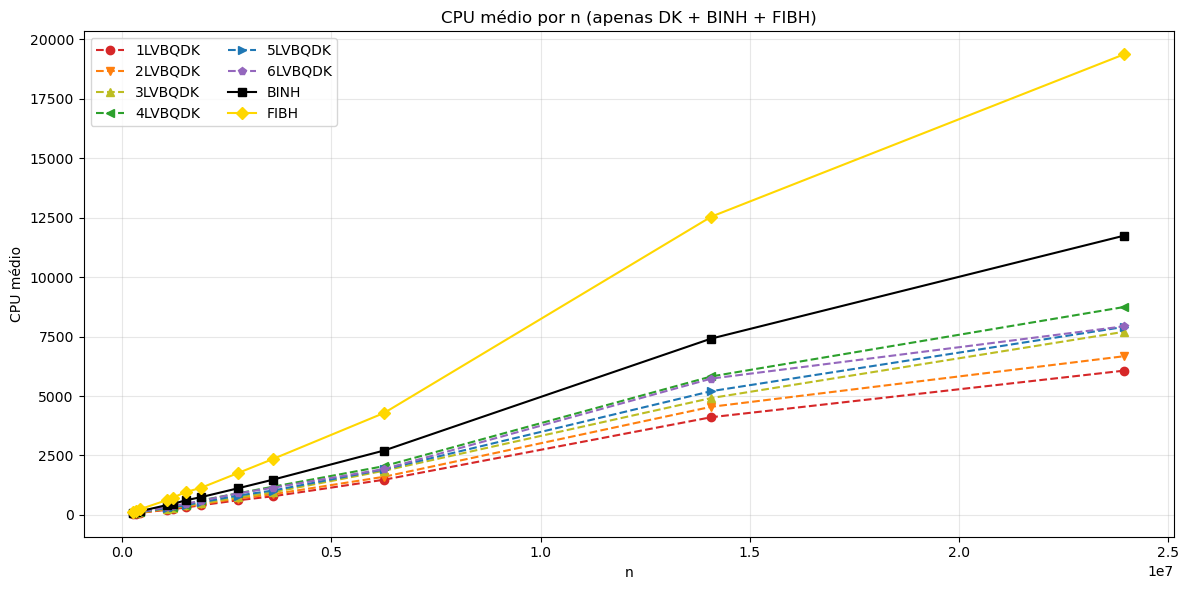

In [17]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **apenas DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQDK$"))  # somente LVBQ DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ DK (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "--"  # DK → tracejado
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n (apenas DK + BINH + FIBH)")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Outras métricas

In [18]:
df_tcache.head(10)

,nome,n,m,c,insert,extractMin,dk,bkmp,fila,cpu_time,wall_time,l1_miss,l2_ref,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
840,NY,264346,733846,36946,299281,299281,0,814144,1LVBQ,68,68,3242667,1763082,142263,292740532,592759898,31379,0,82901416,961343
841,NY,264346,733846,36946,298897,298897,0,710775,1LVBQ,66,66,3218294,1735865,128238,285684978,588428866,28742,0,82619426,949631
842,NY,264346,733846,36946,298704,298704,0,748419,1LVBQ,67,67,3237057,1754591,129032,288178376,590149960,30672,0,82784886,946655
843,NY,264346,733846,36946,299164,299164,0,1247227,1LVBQ,69,69,3319877,1903455,146813,297059002,604100121,24747,0,83349872,949344
844,NY,264346,733846,36946,298201,298201,0,993562,1LVBQ,67,67,3266368,1831590,135042,290416052,595941019,26205,0,82887332,946522
845,NY,264346,733846,36946,298223,298223,0,810802,1LVBQ,68,68,3253678,1813009,143430,295084842,596346340,34467,0,83591753,960745
846,NY,264346,733846,36946,299050,299050,0,990185,1LVBQ,68,68,3243385,1807940,150841,296116486,593872232,26697,0,82544063,943722
847,NY,264346,733846,36946,298949,298949,0,1152025,1LVBQ,66,66,3319939,1871097,117168,285587630,603287695,26491,0,83559687,928064
848,NY,264346,733846,36946,299665,299665,0,1035096,1LVBQ,67,67,3285908,1827437,131007,287201893,596615553,26864,0,82813903,946282
849,NY,264346,733846,36946,299499,299499,0,936323,1LVBQ,67,67,3269541,1800373,132555,289662269,594677635,28204,0,82839430,953005


In [19]:
df_tcache['ipc'] = df_tcache['inst'] / df_tcache['cycles']

### Eficiência de Cache

In [20]:
# normalizar
df_cache = df_tcache[
    ['nome', 'fila', 'inst', 'l1_miss', 'llc_miss']
].copy()

inst_safe = df_cache["inst"].replace(0, np.nan)

df_cache["l1_pi"]  = df_cache["l1_miss"]  / inst_safe
df_cache["llc_pi"] = df_cache["llc_miss"] / inst_safe


# agregar
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           l1_mean=('l1_pi', 'mean'),
           l1_std =('l1_pi', 'std'),
           l1_var =('l1_pi', 'var'),
           llc_mean=('llc_pi', 'mean'),
           llc_std =('llc_pi', 'std'),
           llc_var =('llc_pi', 'var'),
      )
)

df_cache['l1_cv']  = df_cache['l1_std']  / df_cache['l1_mean']
df_cache['llc_cv'] = df_cache['llc_std'] / df_cache['llc_mean']

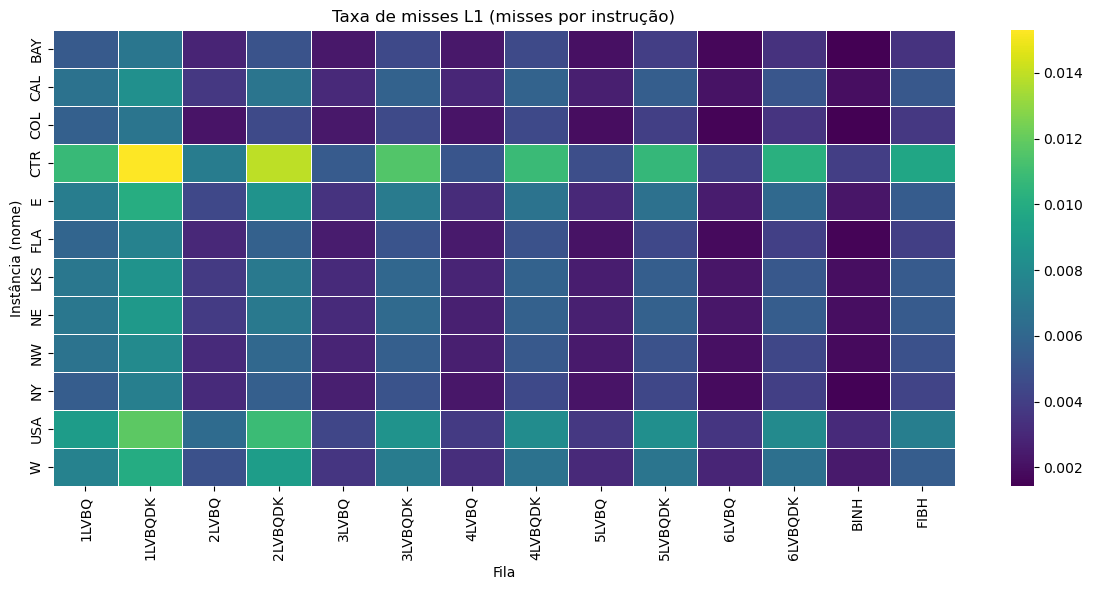

In [21]:

# ===== métrica escolhida =====
df_plot = df_cache.copy()

# opção A: L1 apenas
df_plot["miss"] = df_plot["l1_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="miss")
heat = heat.sort_index().sort_index(axis=1)

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Taxa de misses L1 (misses por instrução)")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

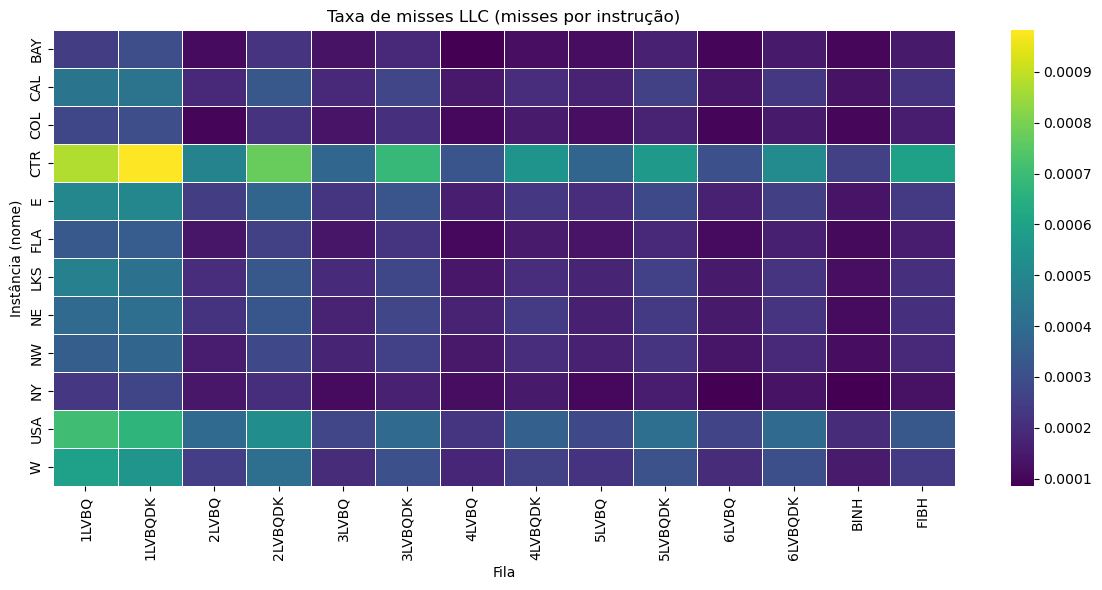

In [22]:

# ===== métrica escolhida =====
df_plot = df_cache.copy()

# opção A: L1 apenas
df_plot["miss"] = df_plot["llc_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="miss")
heat = heat.sort_index().sort_index(axis=1)

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Taxa de misses LLC (misses por instrução)")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### Instruções e cíclos

In [23]:
df_instc = df_tcache[
    ['nome', 'fila', 'inst', 'cycles']
].copy()

df_instc = (
    df_instc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           cycles_total=('cycles', 'sum'),
      )
)

df_instc['ipc'] = (
    df_instc['inst_total'] /
    df_instc['cycles_total'].replace(0, np.nan)
)

df_instc

,nome,fila,inst_total,cycles_total,ipc
0,BAY,1LVBQ,7652135437,3687001151,2.075436
1,BAY,1LVBQDK,5224685477,2690602962,1.941827
2,BAY,2LVBQ,10133811805,3935580419,2.574922
3,BAY,2LVBQDK,6095217289,2999730068,2.031922
4,BAY,3LVBQ,8766927285,3563764660,2.460019
...,...,...,...,...,...
163,W,5LVBQDK,148119342829,80282217674,1.844983
164,W,6LVBQ,191371629600,84361252238,2.268478
165,W,6LVBQDK,150363344959,80785791787,1.861260
166,W,BINH,243758557185,115658323025,2.107575


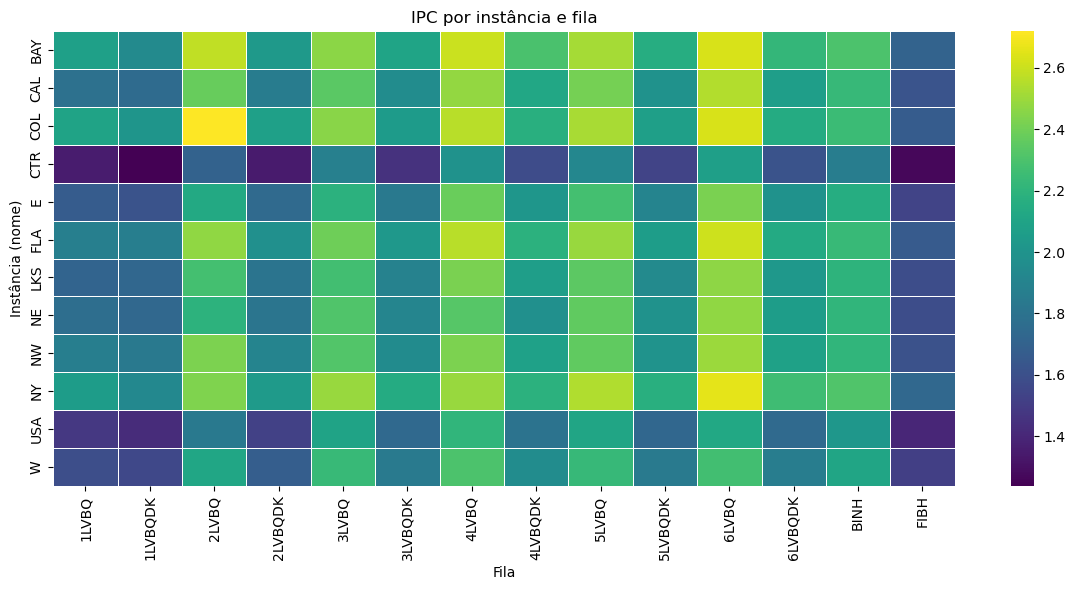

In [24]:

# ===== métrica escolhida =====
df_plot = df_instc.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["ipc"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="ipc")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("IPC por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [25]:
df_inst = df_tcache[
    ['nome', 'fila', 'inst']
].copy()

df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
      )
)

df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_total,inst_mean,inst_std,inst_cv
0,BAY,1LVBQ,7652135437,7.652135e+08,1.046618e+07,0.013677
1,BAY,1LVBQDK,5224685477,5.224685e+08,4.802112e+06,0.009191
2,BAY,2LVBQ,10133811805,1.013381e+09,3.390864e+07,0.033461
3,BAY,2LVBQDK,6095217289,6.095217e+08,6.769514e+06,0.011106
4,BAY,3LVBQ,8766927285,8.766927e+08,2.440465e+06,0.002784
...,...,...,...,...,...,...
163,W,5LVBQDK,148119342829,1.481193e+10,6.846182e+06,0.000462
164,W,6LVBQ,191371629600,1.913716e+10,5.035501e+07,0.002631
165,W,6LVBQDK,150363344959,1.503633e+10,2.462938e+07,0.001638
166,W,BINH,243758557185,2.437586e+10,3.384517e+08,0.013885


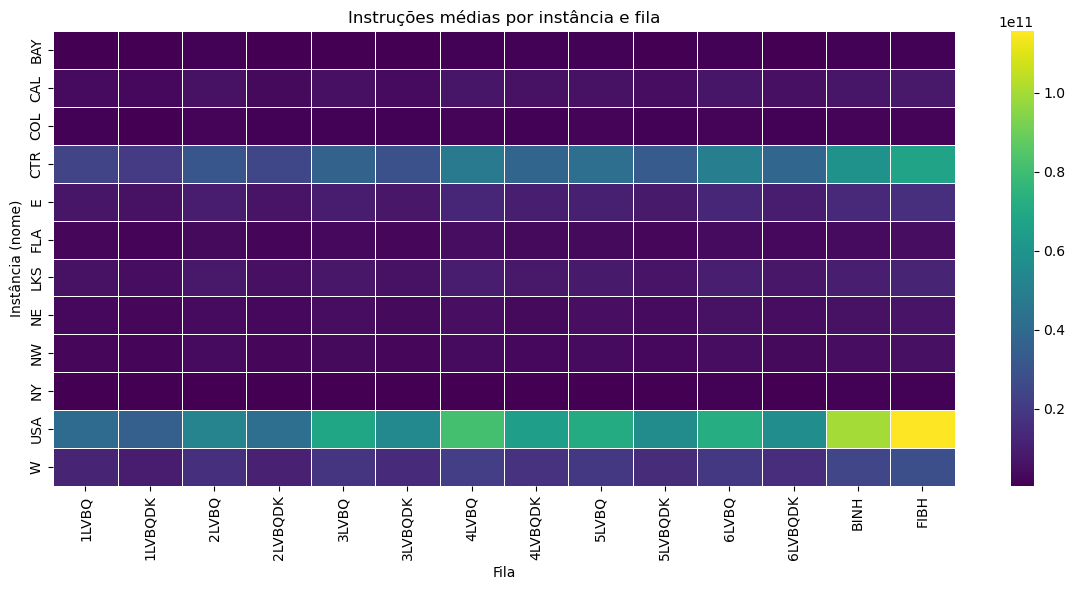

In [26]:

# ===== métrica escolhida =====
df_plot = df_inst.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["inst_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="inst_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Instruções médias por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### Page fault

In [27]:
# normalizar
df_pf = df_tcache[
    ['nome', 'fila', 'inst', 'page_faults']
].copy()

inst_safe = df_pf["inst"].replace(0, np.nan)

df_pf["pf_pi"] = df_pf["page_faults"] / inst_safe

# agregar
df_pf = (
    df_pf.groupby(['nome', 'fila'], as_index=False)
      .agg(
           pf_mean=('pf_pi', 'mean'),
           pf_std =('pf_pi', 'std'),
           pf_var =('pf_pi', 'var'),
      )
)

df_pf['pf_cv'] = df_pf['pf_std'] / df_pf['pf_mean']
df_pf

,nome,fila,pf_mean,pf_std,pf_var,pf_cv
0,BAY,1LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
1,BAY,1LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
2,BAY,2LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
3,BAY,2LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
4,BAY,3LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
...,...,...,...,...,...,...
163,W,5LVBQDK,3.385556e-06,1.733552e-07,3.005201e-14,0.051204
164,W,6LVBQ,6.391269e-07,1.685100e-09,2.839561e-18,0.002637
165,W,6LVBQDK,3.782342e-06,4.722623e-07,2.230317e-13,0.124860
166,W,BINH,1.501049e-07,2.410890e-07,5.812392e-14,1.606137


In [28]:
# normalizar
df_dtlb = df_tcache[
    ['nome', 'fila', 'inst', 'dtlb']
].copy()

inst_safe = df_dtlb["inst"].replace(0, np.nan)

df_dtlb["dtlb_pi"] = df_dtlb["dtlb"] / inst_safe

# agregar
df_dtlb = (
    df_dtlb.groupby(['nome', 'fila'], as_index=False)
      .agg(
           dtlb_mean=('dtlb_pi', 'mean'),
           dtlb_std=('dtlb_pi', 'std'),
           dtlb_var=('dtlb_pi', 'var'),
      )
)

df_dtlb['dtlb_cv'] = df_dtlb['dtlb_std'] / df_dtlb['dtlb_mean']
df_dtlb

,nome,fila,dtlb_mean,dtlb_std,dtlb_var,dtlb_cv
0,BAY,1LVBQ,0.000063,0.000005,2.543462e-11,0.079612
1,BAY,1LVBQDK,0.000059,0.000008,5.868438e-11,0.129743
2,BAY,2LVBQ,0.000026,0.000005,2.861750e-11,0.209357
3,BAY,2LVBQDK,0.000048,0.000012,1.328692e-10,0.238622
4,BAY,3LVBQ,0.000029,0.000005,2.478072e-11,0.170005
...,...,...,...,...,...,...
163,W,5LVBQDK,0.000466,0.000110,1.199268e-08,0.235148
164,W,6LVBQ,0.000173,0.000049,2.438816e-09,0.285679
165,W,6LVBQDK,0.000411,0.000133,1.771768e-08,0.323636
166,W,BINH,0.000134,0.000028,7.720423e-10,0.206705


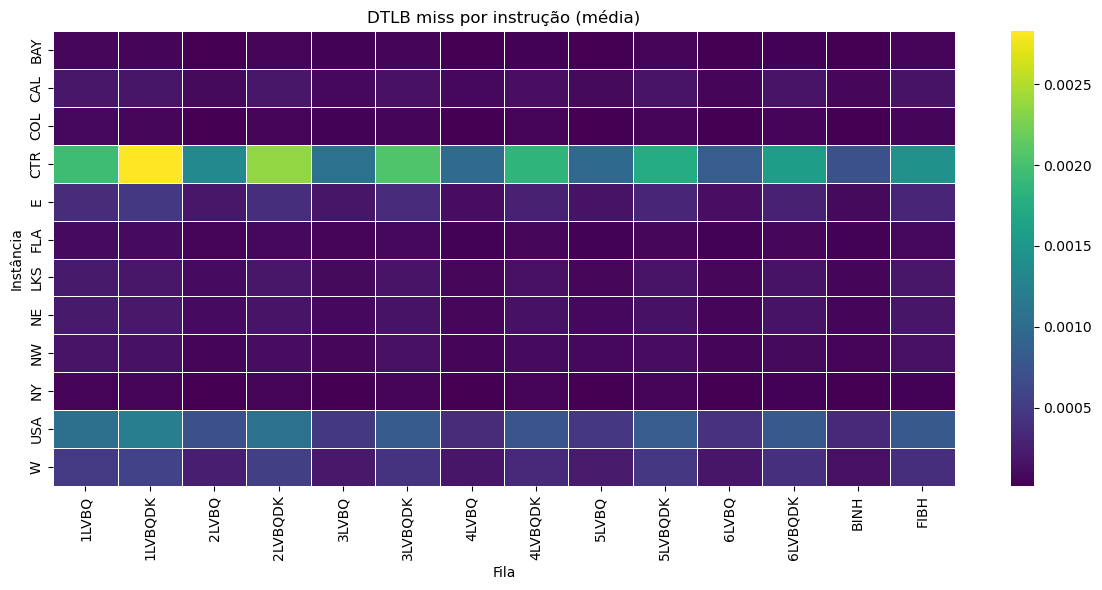

In [29]:
# ===== métrica escolhida =====
df_plot = df_dtlb.copy()

# ===== pivot =====
heat = df_dtlb.pivot(index="nome", columns="fila", values="dtlb_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("DTLB miss por instrução (média)")
plt.xlabel("Fila")
plt.ylabel("Instância")

plt.tight_layout()
plt.show()

### Branch

In [30]:
# normalizar
df_branches = df_tcache[
    ['nome', 'fila', 'branch_miss', 'branch_inst']
].copy()
inst_safe = df_branches["branch_inst"].replace(0, np.nan)
df_branches['bm_rate'] = df_branches['branch_miss'] / inst_safe

# agregar
df_branches = (
    df_branches.groupby(['nome', 'fila'], as_index=False)
      .agg(
           bm_mean=('bm_rate', 'mean'),
           bm_std =('bm_rate', 'std'),
           bm_var =('bm_rate', 'var'),
      )
)
df_branches['bm_cv'] = df_branches['bm_std'] / df_branches['bm_mean']
df_branches

,nome,fila,bm_mean,bm_std,bm_var,bm_cv
0,BAY,1LVBQ,0.010515,0.000111,1.240315e-08,0.010591
1,BAY,1LVBQDK,0.015396,0.000243,5.893588e-08,0.015769
2,BAY,2LVBQ,0.006236,0.000222,4.922750e-08,0.035580
3,BAY,2LVBQDK,0.014778,0.000218,4.767570e-08,0.014775
4,BAY,3LVBQ,0.007844,0.000219,4.816820e-08,0.027980
...,...,...,...,...,...,...
163,W,5LVBQDK,0.013670,0.000480,2.306893e-07,0.035134
164,W,6LVBQ,0.006878,0.000125,1.557236e-08,0.018144
165,W,6LVBQDK,0.013689,0.000718,5.153297e-07,0.052441
166,W,BINH,0.015670,0.000080,6.390348e-09,0.005101


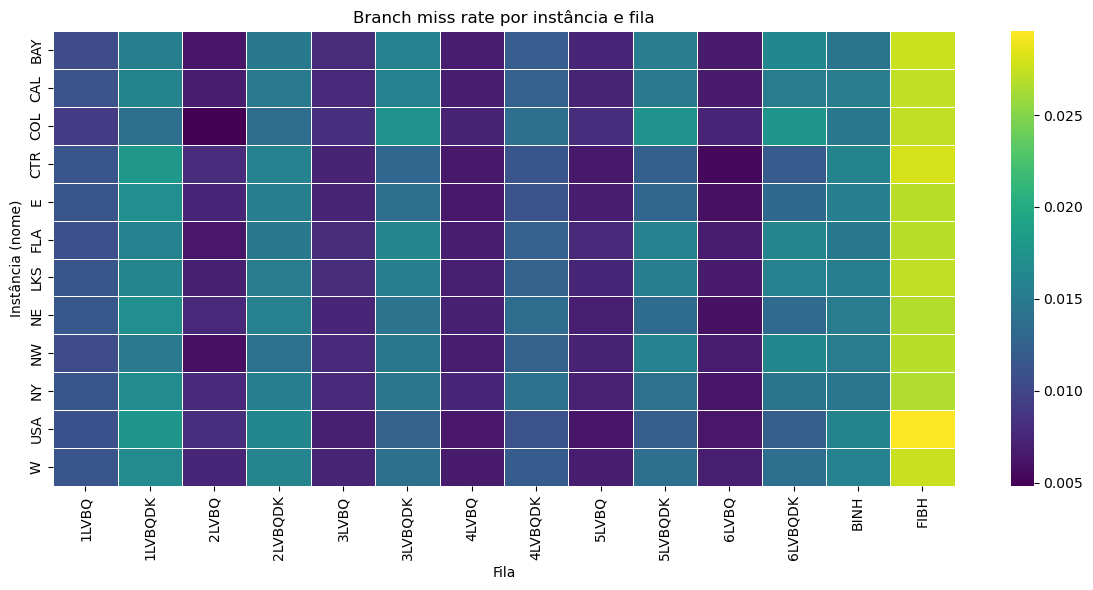

In [31]:

# ===== métrica escolhida =====
df_plot = df_branches.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["bm_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="bm_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Branch miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [32]:
df_inst = df_tcache[
    ['nome', 'n', 'c', 'fila', 'inst']
].copy()
df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
           inst_var =('inst', 'var'),
           n=('n', 'first'),
      )
)
df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_mean,inst_std,inst_var,n,inst_cv
0,BAY,1LVBQ,7.652135e+08,1.046618e+07,1.095409e+14,321270,0.013677
1,BAY,1LVBQDK,5.224685e+08,4.802112e+06,2.306028e+13,321270,0.009191
2,BAY,2LVBQ,1.013381e+09,3.390864e+07,1.149796e+15,321270,0.033461
3,BAY,2LVBQDK,6.095217e+08,6.769514e+06,4.582633e+13,321270,0.011106
4,BAY,3LVBQ,8.766927e+08,2.440465e+06,5.955868e+12,321270,0.002784
...,...,...,...,...,...,...,...
163,W,5LVBQDK,1.481193e+10,6.846182e+06,4.687020e+13,6262104,0.000462
164,W,6LVBQ,1.913716e+10,5.035501e+07,2.535628e+15,6262104,0.002631
165,W,6LVBQDK,1.503633e+10,2.462938e+07,6.066064e+14,6262104,0.001638
166,W,BINH,2.437586e+10,3.384517e+08,1.145496e+17,6262104,0.013885


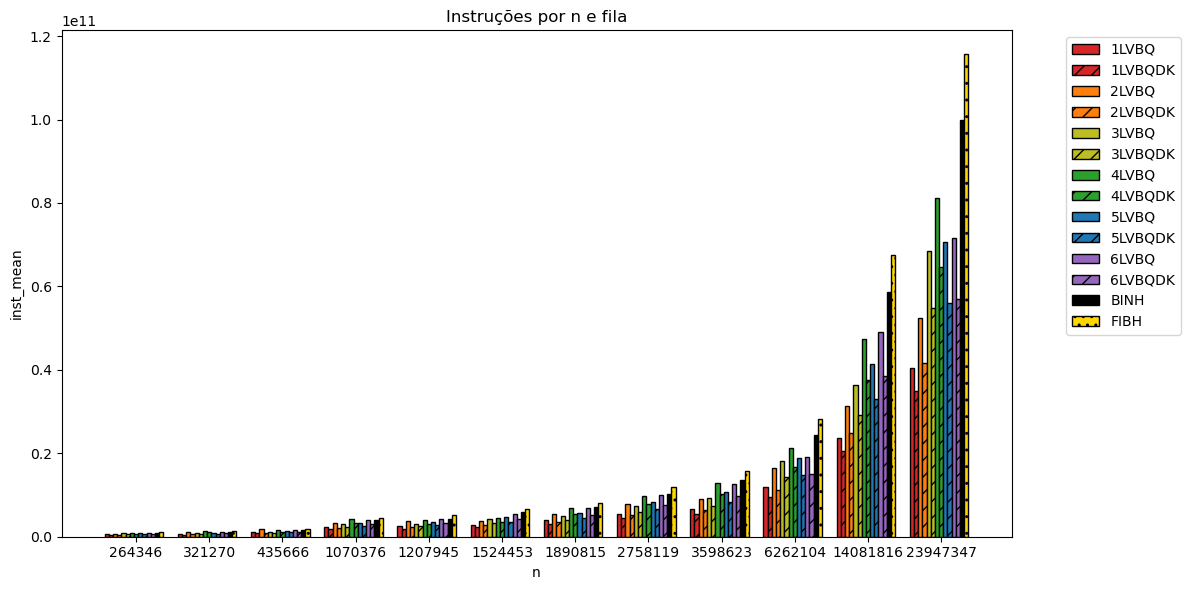

In [33]:
pivot = df_inst.pivot_table(
    index="n",
    columns="fila",
    values="inst_mean",   # 👈 agora é l1_miss
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("inst_mean")  # 👈 eixo Y atualizado
plt.title("Instruções por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Cache miss

In [34]:
df_cache = df_tcache[
    ['nome', 'n', 'c', 'fila', 'l1_miss']
].copy()
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           l1_mean=('l1_miss', 'mean'),
           l1_std =('l1_miss', 'std'),
           l1_var =('l1_miss', 'var'),
           n=('n', 'first'),
      )
)
df_cache['l1_cv'] = df_cache['l1_std'] / df_cache['l1_mean']
df_cache

,nome,fila,l1_mean,l1_std,l1_var,n,l1_cv
0,BAY,1LVBQ,4073911.9,7.955053e+04,6.328287e+09,321270,0.019527
1,BAY,1LVBQDK,3597214.1,7.130175e+04,5.083940e+09,321270,0.019821
2,BAY,2LVBQ,2860826.5,1.011737e+05,1.023611e+10,321270,0.035365
3,BAY,2LVBQDK,3053130.6,2.384162e+05,5.684227e+10,321270,0.078089
4,BAY,3LVBQ,2043337.3,1.006529e+05,1.013100e+10,321270,0.049259
...,...,...,...,...,...,...,...
163,W,5LVBQDK,101206819.1,5.928903e+06,3.515189e+13,6262104,0.058582
164,W,6LVBQ,55197109.2,2.438335e+06,5.945476e+12,6262104,0.044175
165,W,6LVBQDK,98144979.3,7.129482e+06,5.082952e+13,6262104,0.072642
166,W,BINH,57877289.3,3.699327e+06,1.368502e+13,6262104,0.063917


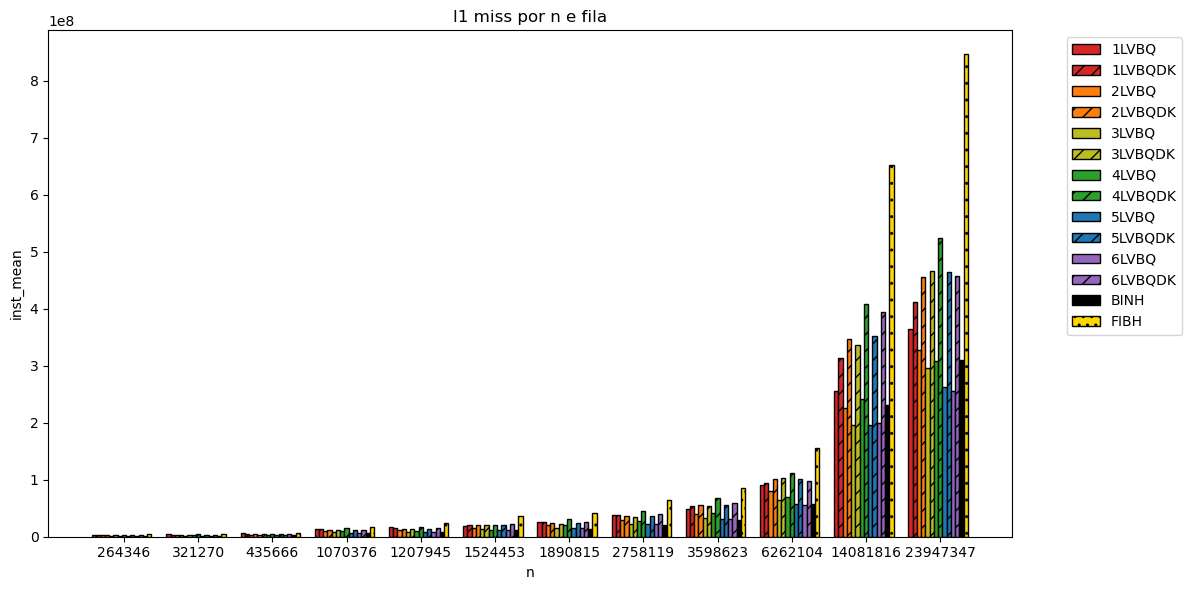

In [35]:
pivot = df_cache.pivot_table(
    index="n",
    columns="fila",
    values="l1_mean",   # 👈 agora é l1_miss
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("inst_mean")  # 👈 eixo Y atualizado
plt.title("l1 miss por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

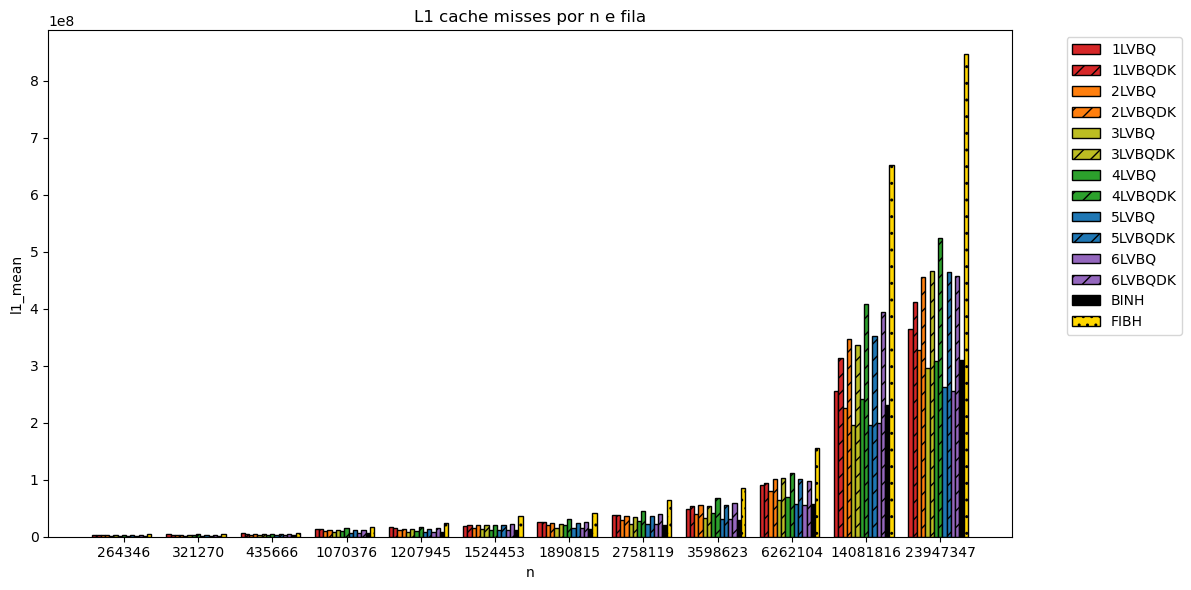

In [36]:
pivot = df_cache.pivot_table(
    index="n",
    columns="fila",
    values="l1_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("l1_mean")
plt.title("L1 cache misses por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [37]:
df_cache = df_tcache[
    ['nome', 'n', 'c', 'fila', 'llc_miss']
].copy()
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           llc_mean=('llc_miss', 'mean'),
           llc_std =('llc_miss', 'std'),
           llc_var =('llc_miss', 'var'),
           n=('n', 'first'),
      )
)
df_cache['llc_cv'] = df_cache['llc_std'] / df_cache['llc_mean']
df_cache

,nome,fila,llc_mean,llc_std,llc_var,n,llc_cv
0,BAY,1LVBQ,188916.5,10733.496513,1.152079e+08,321270,0.056816
1,BAY,1LVBQDK,155834.2,9982.666397,9.965363e+07,321270,0.064060
2,BAY,2LVBQ,114641.5,5050.569082,2.550825e+07,321270,0.044055
3,BAY,2LVBQDK,135261.2,7534.927070,5.677513e+07,321270,0.055706
4,BAY,3LVBQ,112447.6,8010.838203,6.417353e+07,321270,0.071241
...,...,...,...,...,...,...,...
163,W,5LVBQDK,4615236.5,285677.724140,8.161176e+10,6262104,0.061899
164,W,6LVBQ,3776841.7,289515.232105,8.381907e+10,6262104,0.076655
165,W,6LVBQDK,4549405.7,398880.479315,1.591056e+11,6262104,0.087677
166,W,BINH,3705343.3,394803.294361,1.558696e+11,6262104,0.106550


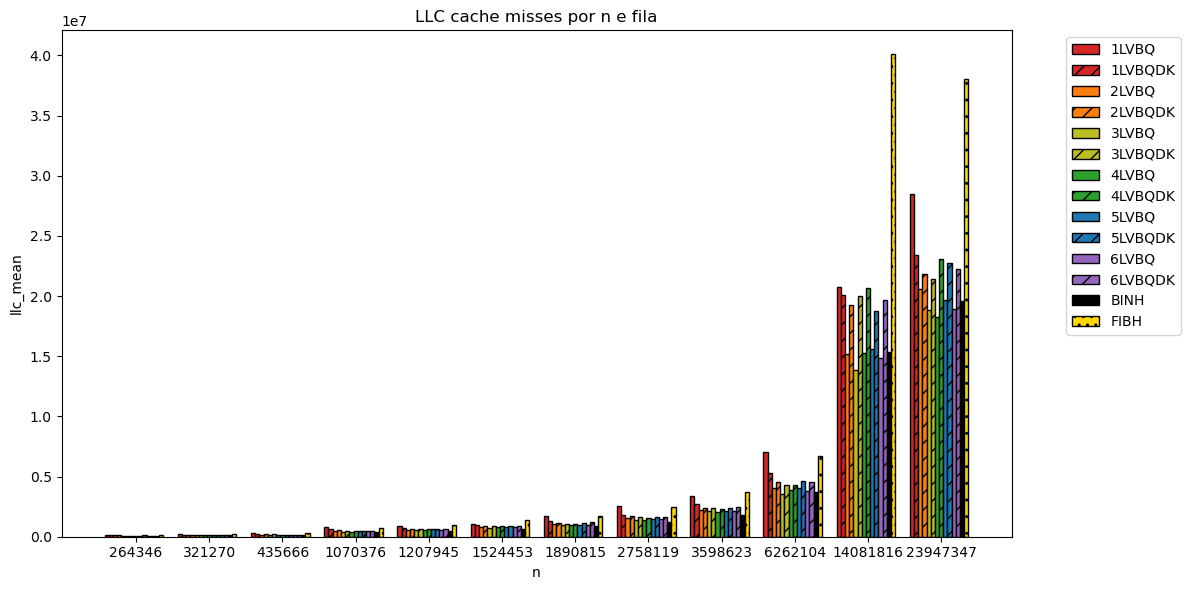

In [38]:
pivot = df_cache.pivot_table(
    index="n",
    columns="fila",
    values="llc_mean",   # 👈 agora é l1_miss
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("llc_mean")  # 👈 eixo Y atualizado
plt.title("LLC cache misses por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()